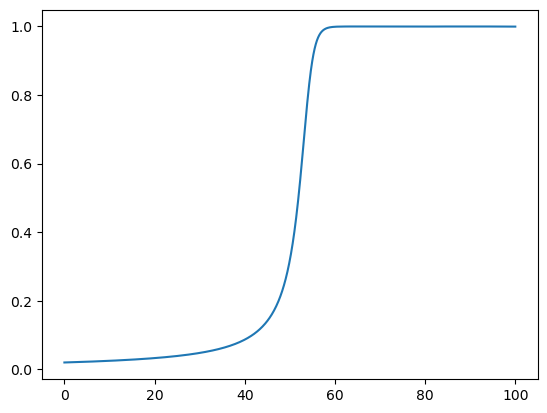

In [22]:
import numpy as np
import matplotlib.pyplot as plt


def f_func(t, y):
    return y**2-y**3


def RK(f_func, t0, tf, y0, h0, reps, aeps):
    t = [t0]
    y = [y0]
    h = h0

    # RK coefficients
    c2, c3 = 1/2, 1
    a21 = 1/2
    a31, a32 = 1/2, 1/2
    b1, b2, b3 = 1/6, 2/3, 1/6

    # Embedded error coefficients
    d1 = 1/6 - 1/2
    d2 = 2/3 - 1/2
    d3 = 1/6 - 0

    while t[-1] < tf:
        tn = t[-1]
        yn = y[-1]

        if tn + h > tf:
            h = tf-tn

        while True:
            # stages
            f1 = f_func(tn, yn)
            f2 = f_func(tn + c2*h, yn + a21*h*f1)
            f3 = f_func(tn + c3*h, yn + a31*h*f1 + a32*h*f2)

            # solution
            yn1 = yn + h*(b1*f1 + b2*f2 + b3*f3)

            # error estimate
            err = abs(h*(d1*f1 + d2*f2 + d3*f3))

            tol = reps * abs(yn) + aeps

            if err <= tol:
                break  # accept step

            # reduce step
            h = h/2

        # accept step
        t.append(tn + h)
        y.append(yn1)

        # increase step
        h = h0

    return np.array(t), np.array(y)




delta = 0.02
h0 = 50
reps = 1e-4
aeps = 1e-6

t, y = RK(f_func, 0, 2/delta, delta, h0, reps, aeps)

plt.plot(t,y)

In [23]:
len(t)

400

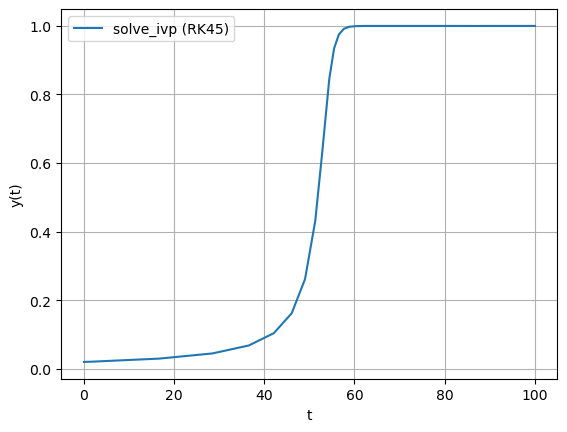

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return y**2 - y**3

# parameters
delta = 0.02
t0 = 0
tf = 2 / delta
y0 = [delta]

# solve
sol = solve_ivp(
    f,
    (t0, tf),
    y0,
    method='RK45',          # similar to ode45
    rtol=1e-4,             # relative tolerance
    atol=1e-6              # absolute tolerance
)

# plot
plt.plot(sol.t, sol.y[0], label="solve_ivp (RK45)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.legend()
plt.grid()
plt.show()

In [24]:
len(sol.t)

30